In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# 1. Генерируем 30 точек от 0 до 3 (исходный 1D-признак X)
X_raw = np.sort(np.random.uniform(0, 3, size=30))

# 2. Настоящий закон природы (нелинейный): y = sin(X * 3) + noise
y = np.sin(X_raw * 3) + np.random.normal(0, 0.2, size=30)

# 3. Делим 30 точек на Train (20 точек) и Test (10 точек)
train_idx = np.random.choice(30, size=20, replace=False)
test_idx = np.array([i for i in range(30) if i not in train_idx])

X_train, y_train = X_raw[train_idx], y[train_idx]
X_test, y_test = X_raw[test_idx], y[test_idx]

print(f"Размер train: {len(X_train)}, размер test: {len(X_test)}")

Размер train: 20, размер test: 10


In [2]:
# 1
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

def fit_and_evaluate(degree, X_tr, y_tr, X_te, y_te):
    poly = PolynomialFeatures(degree=degree, include_bias=False)

    X_tr = poly.fit_transform(X_tr.reshape(-1, 1))
    X_te = poly.fit_transform(X_te.reshape(-1, 1))

    model = LinearRegression()
    model.fit(X_tr, y_tr)

    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)

    mse_tr = mean_squared_error(y_pred_tr, y_tr)
    mse_te = mean_squared_error(y_pred_te, y_te)

    return model, mse_tr, mse_te

In [13]:
# 2, 3
model, mse_tr, mse_te = fit_and_evaluate(1, X_train, y_train, X_test, y_test)
print(model.coef_)
print('1)', mse_tr, mse_te)

model, mse_tr, mse_te = fit_and_evaluate(3, X_train, y_train, X_test, y_test)
print(model.coef_)
print('2)', mse_tr, mse_te)

model, mse_tr, mse_te = fit_and_evaluate(9, X_train, y_train, X_test, y_test)
print(model.coef_)
print('3)', mse_tr, mse_te)

[-0.0916235]
1) 0.6235796244975441 0.5373776379477511
[ 0.18811441 -1.54546966  0.53187348]
2) 0.1659361587041131 0.43832731024732874
[ 5.13406096 -3.58205075 -3.04657985  0.57201888  1.81228208  0.01536334
 -0.80055238  0.32145721 -0.03845054]
3) 0.022581465483432442 0.054593447295976115


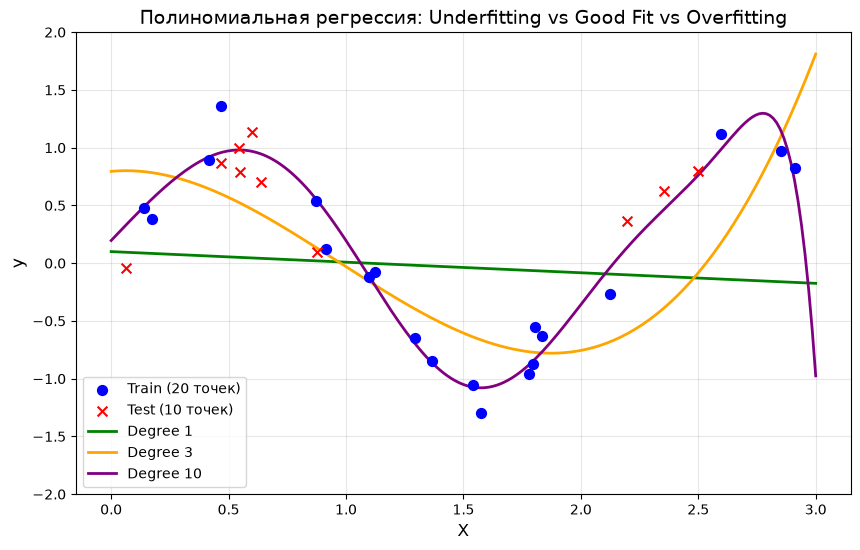

In [17]:
# 4
X_grid = np.linspace(0, 3, 200)

plt.figure(figsize=(10, 6))

plt.scatter(X_train, y_train, color='blue', label='Train (20 точек)', s=50, zorder=5)
plt.scatter(X_test, y_test, color='red', marker='x', label='Test (10 точек)', s=50, zorder=5)

degrees = [1, 3, 10]
colors = ['green', 'orange', 'purple']

for deg, col in zip(degrees, colors):
    poly = PolynomialFeatures(degree=deg, include_bias=False)
    X_tr_poly = poly.fit_transform(X_train.reshape(-1, 1))

    model = LinearRegression()
    model.fit(X_tr_poly, y_train)

    X_grid_poly = poly.transform(X_grid.reshape(-1, 1))
    y_grid_pred = model.predict(X_grid_poly)

    plt.plot(X_grid, y_grid_pred, label=f'Degree {deg}', color=col, linewidth=2)

    plt.title("Полиномиальная регрессия: Underfitting vs Good Fit vs Overfitting", fontsize=14)
plt.xlabel("X", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.ylim(-2, 2)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()
